In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
noise_levels = [0.1, 0.3, 0.5]
blur_sigma = 2.0
sample_idx = 0  
base_dir = './constant_scale_results'
save_dir = './test_result_figures'
os.makedirs(save_dir, exist_ok=True)

In [3]:
rows = []
for noise in noise_levels:
    subpath = f"deblur/blur={blur_sigma}_noise={noise}/admm/lpn"

    lpn_path = os.path.join(base_dir, "LPN", subpath)
    ne_path = os.path.join(base_dir, "NE", subpath)
    small_path = os.path.join(base_dir, "LPN_64ch", subpath)

    noisy = np.load(os.path.join(ne_path, 'y', f'{sample_idx}.npy'))
    lpn_out = np.load(os.path.join(lpn_path, 'xhat', f'{sample_idx}.npy'))
    ne_out = np.load(os.path.join(ne_path, 'xhat', f'{sample_idx}.npy'))
    small_out = np.load(os.path.join(small_path, 'xhat', f'{sample_idx}.npy'))
    ground_truth = np.load(os.path.join(ne_path, 'x', f'{sample_idx}.npy'))

    rows.append([noisy, lpn_out, ne_out, small_out, ground_truth])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

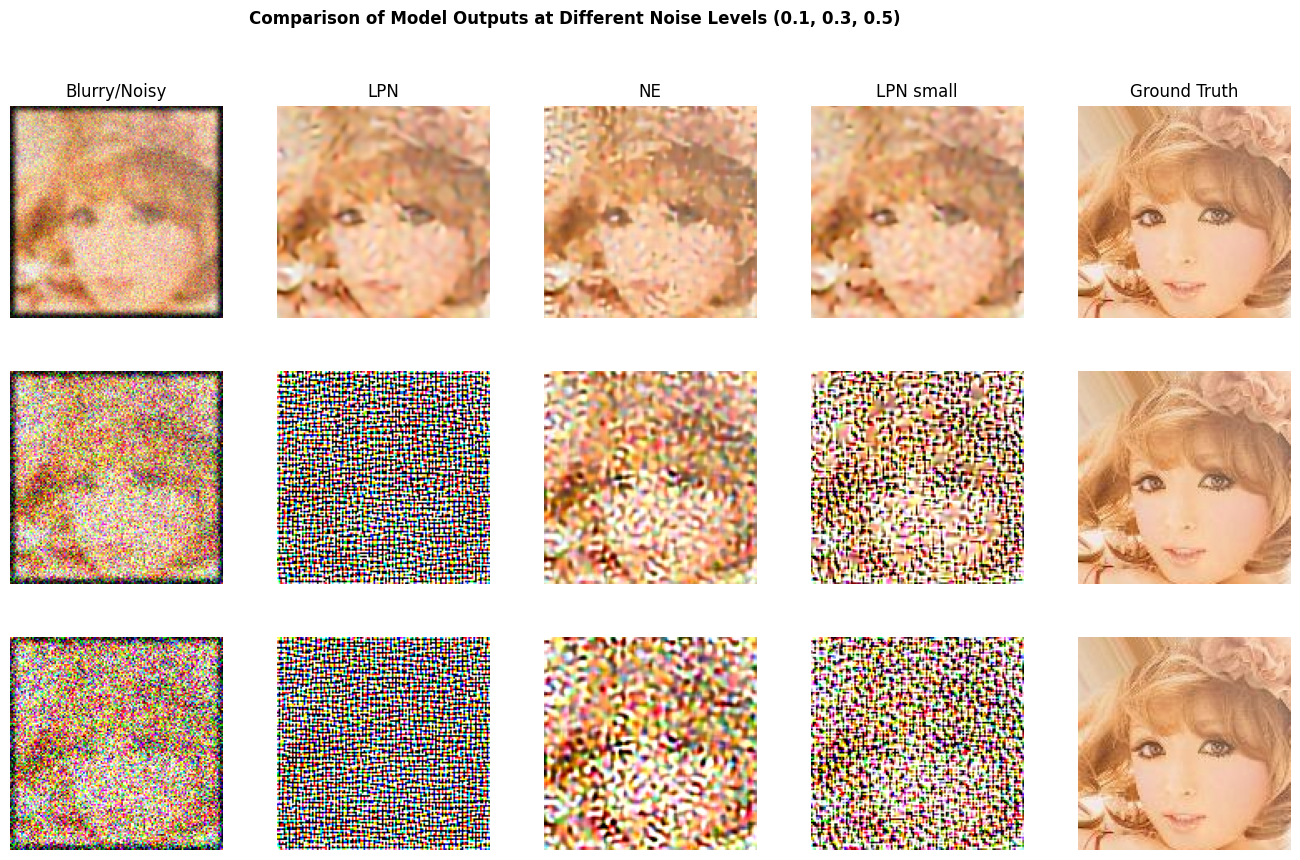

Saved figure to: ./test_result_figures/comparison_noise_levels_3rows_0.png


In [4]:
# Plot
fig, axes = plt.subplots(len(noise_levels), 5, figsize=(15, 9))

column_titles = ["Blurry/Noisy", "LPN", "NE", "LPN small", "Ground Truth"]
for col, title in enumerate(column_titles):
    axes[0, col].set_title(title, fontsize=12)

# Fill images and y-axis labels
for row_idx, noise in enumerate(noise_levels):
    for col_idx in range(5):
        ax = axes[row_idx, col_idx]
        ax.imshow(rows[row_idx][col_idx])
        ax.axis('off')
    
    # Y-axis label on leftmost subplot
    axes[row_idx, 0].set_ylabel(f"$\\sigma_{{noise}}$ = {noise}", fontsize=12, rotation=90, labelpad=20)

# Title and layout
plt.suptitle("Comparison of Model Outputs at Different Noise Levels (0.1, 0.3, 0.5)", fontsize=12, fontweight='bold')

# Better layout for y-axis labels to show
plt.tight_layout(rect=[0.07, 0.03, 1, 0.95])  # more space for y-axis labels
plt.subplots_adjust(left=0.11, hspace=0.25)   # increase left padding

# Save
save_path = os.path.join(save_dir, f"comparison_noise_levels_3rows_{sample_idx}.png")
plt.savefig(save_path, dpi=300)
plt.show()
print(f"Saved figure to: {save_path}")

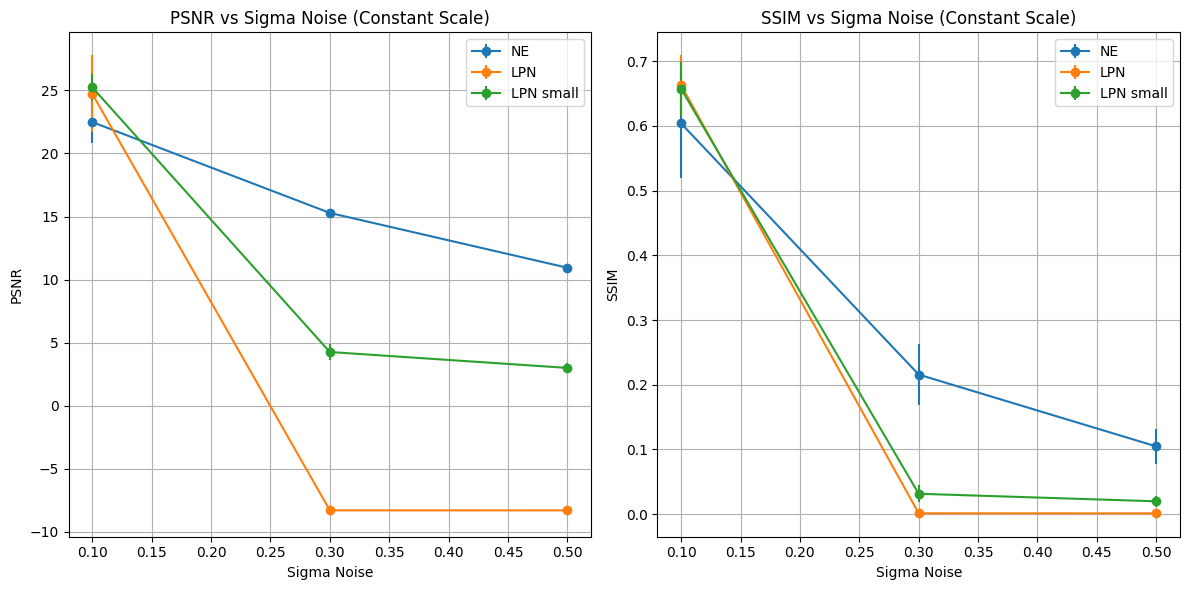

Saved plot to ./test_result_figures/psnr_ssim_vs_noise_constant_scale.png


In [ ]:
sigma_noise = np.array([0.1, 0.3, 0.5])

# Load data
NE_PSNRs = np.load(os.path.join(base_dir, "NE_PSNRs.npy"))
NE_SSIMs = np.load(os.path.join(base_dir, "NE_SSIMs.npy"))

LPN_PSNRs = np.load(os.path.join(base_dir, "LPN_PSNRs.npy"))
LPN_SSIMs = np.load(os.path.join(base_dir, "LPN_SSIMs.npy"))

LPN_small_PSNRs = np.load(os.path.join(base_dir, "LPN_small_PSNRs.npy"))
LPN_small_SSIMs = np.load(os.path.join(base_dir, "LPN_small_SSIMs.npy"))

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# PSNR
ax[0].errorbar(sigma_noise, NE_PSNRs[:, 0], yerr=NE_PSNRs[:, 1], label='NE', fmt='-o')
ax[0].errorbar(sigma_noise, LPN_PSNRs[:, 0], yerr=LPN_PSNRs[:, 1], label='LPN', fmt='-o')
ax[0].errorbar(sigma_noise, LPN_small_PSNRs[:, 0], yerr=LPN_small_PSNRs[:, 1], label='LPN small', fmt='-o')
ax[0].set_xlabel(r'$\sigma_{\mathrm{noise}}$')
ax[0].set_ylabel('PSNR')
ax[0].set_title(r'PSNR vs $\sigma_{\mathrm{noise}}$ (Constant Scale)')
ax[0].legend()
ax[0].grid(True)

# SSIM
ax[1].errorbar(sigma_noise, NE_SSIMs[:, 0], yerr=NE_SSIMs[:, 1], label='NE', fmt='-o')
ax[1].errorbar(sigma_noise, LPN_SSIMs[:, 0], yerr=LPN_SSIMs[:, 1], label='LPN', fmt='-o')
ax[1].errorbar(sigma_noise, LPN_small_SSIMs[:, 0], yerr=LPN_small_SSIMs[:, 1], label='LPN small', fmt='-o')
ax[1].set_xlabel(r'$\sigma_{\mathrm{noise}}$')
ax[1].set_ylabel('SSIM')
ax[1].set_title(r'SSIM vs $\sigma_{\mathrm{noise}}$ (Constant Scale)')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()

# Save
save_path = os.path.join(save_dir, "psnr_ssim_vs_noise_constant_scale.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Saved plot to {save_path}")